# Movie Recommender

A collaborative filtering movie recommendation system built using K-Nearest Neighbors (KNN) and cosine similarity on the MovieLens dataset.



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

## 1. Load and Prepare the Data


In [6]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

ratings = ratings.merge(
    movies[["movieId", "title"]],
    on="movieId",
    how="left"
)

ratings = ratings[["userId", "movieId", "title", "rating"]]

ratings.head()

,userId,movieId,title,rating
0,1,31,Dangerous Minds (1995),2.5
1,1,1029,Dumbo (1941),3.0
2,1,1061,Sleepers (1996),3.0
3,1,1129,Escape from New York (1981),2.0
4,1,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),4.0


## 2. Data Quality Check


In [7]:
print("Shape:", ratings.shape)
print("\nColumns:")
print(ratings.columns.tolist())

print("\nMissing values:")
print(ratings.isnull().sum())

print("\nDuplicates:", ratings.duplicated().sum())

Shape: (100004, 4)

Columns:
['userId', 'movieId', 'title', 'rating']

Missing values:
userId     0
movieId    0
title      0
rating     0
dtype: int64

Duplicates: 0


## 3. Movie-Level Analysis


In [8]:
movie_stats = (
    ratings.groupby(["movieId", "title"])
    .agg(
        rating_count=("rating", "count"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(10)

,movieId,title,rating_count,avg_rating
321,356,Forrest Gump (1994),341,4.054252
266,296,Pulp Fiction (1994),324,4.256173
284,318,"Shawshank Redemption, The (1994)",311,4.487138
525,593,"Silence of the Lambs, The (1991)",304,4.138158
232,260,Star Wars: Episode IV - A New Hope (1977),291,4.221649
427,480,Jurassic Park (1993),274,3.706204
2062,2571,"Matrix, The (1999)",259,4.183398
0,1,Toy Story (1995),247,3.872470
472,527,Schindler's List (1993),244,4.303279
522,589,Terminator 2: Judgment Day (1991),237,4.006329


In [9]:
print("Movies with 10+ ratings:",
      (movie_stats["rating_count"] >= 10).sum())

print("Movies with 20+ ratings:",
      (movie_stats["rating_count"] >= 20).sum())

print("Movies with 50+ ratings:",
      (movie_stats["rating_count"] >= 50).sum())

Movies with 10+ ratings: 2245
Movies with 20+ ratings: 1303
Movies with 50+ ratings: 453


## 4. Rating Distribution


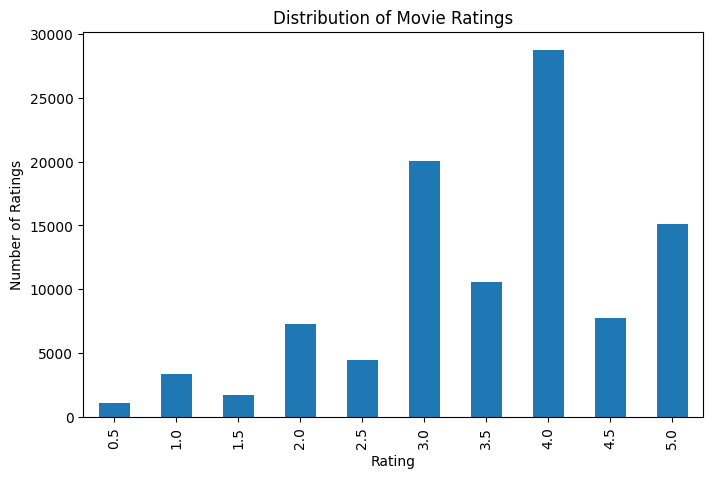

In [10]:
plt.figure(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Movie Ratings")
plt.show()

## 5. Dataset Statistics


In [11]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)

print("Unique users:", n_users)
print("Unique movies:", n_movies)
print("Total ratings:", n_ratings)

Unique users: 671
Unique movies: 9066
Total ratings: 100004


## 6. Popularity and Rating Analysis


In [13]:
popular_movies = movie_stats[movie_stats["rating_count"] >= 50]

popular_movies.sort_values(
    "avg_rating",
    ascending=False
).head(10)

,movieId,title,rating_count,avg_rating
695,858,"Godfather, The (1972)",200,4.487500
284,318,"Shawshank Redemption, The (1994)",311,4.487138
786,969,"African Queen, The (1951)",50,4.420000
734,913,"Maltese Falcon, The (1941)",62,4.387097
977,1221,"Godfather: Part II, The (1974)",135,4.385185
48,50,"Usual Suspects, The (1995)",201,4.370647
984,1228,Raging Bull (1980),50,4.350000
1006,1252,Chinatown (1974),76,4.335526
725,904,Rear Window (1954),92,4.315217
960,1203,12 Angry Men (1957),74,4.304054


## 7. User Activity


In [14]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

user_activity.describe()

,0
count,671.000000
mean,149.037258
std,231.226948
min,20.000000
25%,37.000000
50%,71.000000
75%,161.000000
max,2391.000000


## 8. User Activity Distribution


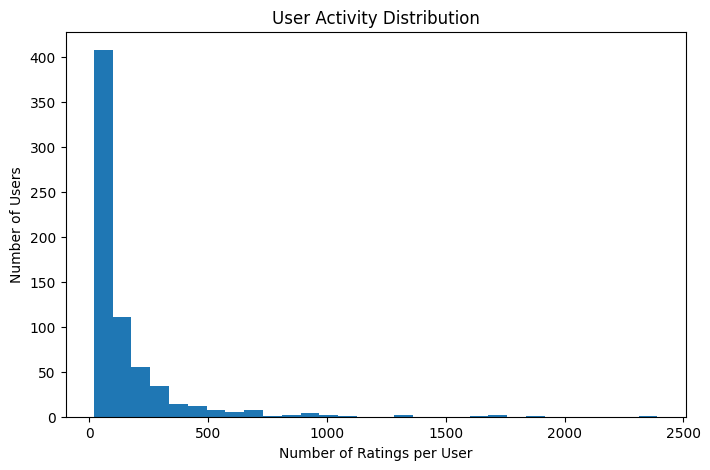

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(user_activity, bins=30)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")
plt.show()

## 9. User–Item Matrix Sparsity


In [16]:
total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print(f"User-item matrix sparsity: {sparsity:.2%}")

User-item matrix sparsity: 98.36%


## 10. Train–Test Split


In [17]:
train, test = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(train))
print("Testing records:", len(test))

Training records: 80003
Testing records: 20001


## 11. Build the User–Item Matrix


In [18]:
user_ids = train["userId"].unique()
movie_ids = train["movieId"].unique()

user_mapper = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}

movie_mapper = {
    movie_id: index
    for index, movie_id in enumerate(movie_ids)
}

movie_inv_mapper = {
    index: movie_id
    for movie_id, index in movie_mapper.items()
}

In [19]:
train_users = train["userId"].map(user_mapper)
train_movies = train["movieId"].map(movie_mapper)

In [20]:
user_item_matrix = csr_matrix(
    (
        train["rating"],
        (train_movies, train_users)
    ),
    shape=(len(movie_mapper), len(user_mapper))
)

print("Matrix shape:", user_item_matrix.shape)

Matrix shape: (8399, 671)


## 12. Build the Recommendation Model


Build the recommendation model

In [21]:
model = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

model.fit(user_item_matrix)
print("KNN collaborative filtering model fitted successfully.")

KNN collaborative filtering model fitted successfully.


## 13. Recommendation Function


Recommendation function

In [22]:
def recommend_movies(
    movie_title,
    ratings,
    movie_stats,
    user_item_matrix,
    movie_mapper,
    movie_inv_mapper,
    model,
    k=5
):

    # Find movies containing the search text
    matches = ratings[
        ratings["title"].str.contains(
          movie_title,
          case=False,
          na=False,
          regex=False
)
    ][["movieId", "title"]].drop_duplicates()

    if matches.empty:
        return "Movie not found."

    # Show matching titles if multiple exist
    if len(matches) > 1:
        print("Multiple matches found:")
        print(matches.head(10).to_string(index=False))

    # Use first matching movie
    movie_id = matches["movieId"].iloc[0]

    if movie_id not in movie_mapper:
        return "Movie exists, but it is not present in the training data."

    movie_index = movie_mapper[movie_id]

    distances, indices = model.kneighbors(
        user_item_matrix[movie_index],
        n_neighbors=k + 1
    )

    recommendations = []

    for distance, index in zip(
        distances.flatten()[1:],
        indices.flatten()[1:]
    ):

        recommended_id = movie_inv_mapper[index]

        movie_info = movie_stats[
            movie_stats["movieId"] == recommended_id
        ]

        if not movie_info.empty:
            recommendations.append({
                "movie": movie_info["title"].iloc[0],
                "similarity": round(1 - distance, 3),
                "avg_rating": round(
                    movie_info["avg_rating"].iloc[0], 2
                ),
                "rating_count": movie_info["rating_count"].iloc[0]
            })

    return pd.DataFrame(recommendations)

## 14. Example: Movie Recommendations


In [23]:
recommendations = recommend_movies(
    "Forrest Gump (1994)",
    ratings,
    movie_stats,
    user_item_matrix,
    movie_mapper,
    movie_inv_mapper,
    model,
    k=10
)

recommendations.sort_values("similarity", ascending=False)

,movie,similarity,avg_rating,rating_count
0,"Silence of the Lambs, The (1991)",0.548,4.14,304
1,Jurassic Park (1993),0.548,3.71,274
2,Terminator 2: Judgment Day (1991),0.525,4.01,237
3,Pulp Fiction (1994),0.524,4.26,324
4,"Shawshank Redemption, The (1994)",0.521,4.49,311
5,Braveheart (1995),0.516,3.95,228
6,Speed (1994),0.506,3.57,180
7,Schindler's List (1993),0.497,4.30,244
8,"Matrix, The (1999)",0.485,4.18,259
9,"Fugitive, The (1993)",0.471,3.95,213


## 15. Popularity Baseline


Build a popularity baseline

In [24]:
# Popularity-based baseline

popular_movies = (
    movie_stats[movie_stats["rating_count"] >= 50]
    .sort_values(
        ["avg_rating", "rating_count"],
        ascending=[False, False]
    )
)

popular_movies.head(10)

,movieId,title,rating_count,avg_rating
695,858,"Godfather, The (1972)",200,4.487500
284,318,"Shawshank Redemption, The (1994)",311,4.487138
786,969,"African Queen, The (1951)",50,4.420000
734,913,"Maltese Falcon, The (1941)",62,4.387097
977,1221,"Godfather: Part II, The (1974)",135,4.385185
48,50,"Usual Suspects, The (1995)",201,4.370647
984,1228,Raging Bull (1980),50,4.350000
1006,1252,Chinatown (1974),76,4.335526
725,904,Rear Window (1954),92,4.315217
960,1203,12 Angry Men (1957),74,4.304054


## 16. Recommendation Evaluation


Evaluate

In [25]:
# Positive interactions = ratings >= 4
POSITIVE_THRESHOLD = 4

# Test users with enough interactions for evaluation
test_user_counts = (
    test[test["rating"] >= POSITIVE_THRESHOLD]
    .groupby("userId")
    .size()
)

eval_users = test_user_counts[
    test_user_counts >= 5
].index

print("Users eligible for evaluation:", len(eval_users))

Users eligible for evaluation: 465


In [26]:
def recommend_for_user(
    user_id,
    train,
    user_item_matrix,
    user_mapper,
    movie_inv_mapper,
    movie_mapper,
    model,
    k=5
):

    # Movies already rated by the user
    user_history = train[
        train["userId"] == user_id
    ]

    if user_history.empty:
        return []

    rated_movies = set(user_history["movieId"])

    candidate_scores = {}

    # Find similar movies to everything the user has rated
    for movie_id in rated_movies:

        if movie_id not in movie_mapper:
            continue

        movie_index = movie_mapper[movie_id]

        distances, indices = model.kneighbors(
            user_item_matrix[movie_index],
            n_neighbors=min(21, user_item_matrix.shape[0])
        )

        for distance, index in zip(
            distances.flatten()[1:],
            indices.flatten()[1:]
        ):

            candidate_id = movie_inv_mapper[index]

            # Don't recommend something the user already watched
            if candidate_id in rated_movies:
                continue

            similarity = 1 - distance

            if candidate_id not in candidate_scores:
                candidate_scores[candidate_id] = []

            candidate_scores[candidate_id].append(similarity)

    # Average similarity across all movies contributing to recommendation
    ranked_candidates = sorted(
        candidate_scores.items(),
        key=lambda x: np.mean(x[1]),
        reverse=True
    )

    return [
        movie_id
        for movie_id, scores in ranked_candidates[:k]
    ]

In [27]:
def evaluate_user(user_id, k=5):

    recommendations = recommend_for_user(
        user_id,
        train,
        user_item_matrix,
        user_mapper,
        movie_inv_mapper,
        movie_mapper,
        model,
        k=k
    )

    if not recommendations:
        return None, None

    actual_movies = set(
        test[
            (test["userId"] == user_id) &
            (test["rating"] >= POSITIVE_THRESHOLD)
        ]["movieId"]
    )

    if not actual_movies:
        return None, None

    hits = len(
        set(recommendations) & actual_movies
    )

    precision = hits / k
    recall = hits / len(actual_movies)

    return precision, recall

In [28]:
precision_scores = []
recall_scores = []

for user_id in eval_users:

    precision, recall = evaluate_user(
        user_id,
        k=5
    )

    if precision is not None:
        precision_scores.append(precision)
        recall_scores.append(recall)

print(
    "Mean Precision@5:",
    round(np.mean(precision_scores), 4)
)

print(
    "Mean Recall@5:",
    round(np.mean(recall_scores), 4)
)

Mean Precision@5: 0.0125
Mean Recall@5: 0.0074


## 17. Recommendation Analysis


Analyze recommendations

In [38]:
# Recommendation coverage across evaluation users

recommended_movies = set()

for user_id in list(eval_users)[:200]:

    recs = recommend_for_user(
        user_id,
        train,
        user_item_matrix,
        user_mapper,
        movie_inv_mapper,
        movie_mapper,
        model,
        k=5
    )

    recommended_movies.update(recs)

coverage = (
    len(recommended_movies) /
    len(movie_mapper)
)

print("Unique recommended movies:", len(recommended_movies))
print("Catalog coverage:", round(coverage * 100, 2), "%")

Unique recommended movies: 766
Catalog coverage: 9.12 %


## 18. Business & Product Insights


Business/Product insights

In [66]:
top_rated = movie_stats[
    movie_stats["rating_count"] >= 50
].sort_values(
    "avg_rating",
    ascending=False
)

top_rated.head(10)

,movieId,title,rating_count,avg_rating
695,858,"Godfather, The (1972)",200,4.487500
284,318,"Shawshank Redemption, The (1994)",311,4.487138
786,969,"African Queen, The (1951)",50,4.420000
734,913,"Maltese Falcon, The (1941)",62,4.387097
977,1221,"Godfather: Part II, The (1974)",135,4.385185
48,50,"Usual Suspects, The (1995)",201,4.370647
984,1228,Raging Bull (1980),50,4.350000
1006,1252,Chinatown (1974),76,4.335526
725,904,Rear Window (1954),92,4.315217
960,1203,12 Angry Men (1957),74,4.304054


In [67]:
print(
    "Average rating:",
    round(ratings["rating"].mean(), 2)
)

print(
    "Median ratings per user:",
    user_activity.median()
)

print(
    "Median ratings per movie:",
    movie_stats["rating_count"].median()
)

Average rating: 3.54
Median ratings per user: 71.0
Median ratings per movie: 3.0


## 19. Key Takeaways

- The dataset contains **100K+ ratings** across **670+ users** and **9K+ movies**.
- The user–movie interaction matrix is highly sparse (**98%+**), motivating a sparse collaborative-filtering approach.
- KNN with cosine similarity generates movie-to-movie recommendations from historical rating patterns.
- The evaluation and catalog-coverage results provide a baseline for future improvements such as matrix factorization or hybrid recommendation models.